# Pre-Analysis: Cyberattack Incidents Dataset

This notebook characterises the dataset **as it will actually be used** by the downstream systems — after all preprocessing steps (missingness deletion, outlier removal, skewness correction, imputation, scaling, and PCA) have been applied.

The goal is not to justify the preprocessing decisions (that is done in "preProcessing.ipynb"), but to answer:
- What does the data look like structurally?
- What is the target variable distribution and is there class imbalance?
- Are there temporal patterns in attack vectors?
- How much information is retained after the preprocessing pipeline?
- What do the PCA components capture?

These observations motivate the design choices made in each downstream system.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

DATA_RAW  = 'data/raw/'
DATA_PROC = 'data/processed/'

PALETTE = sns.color_palette('YlOrRd_r', 10)

## 1. Data Loading

We load both the **raw** data (for categorical and temporal analysis, which are not preserved in the numerical processed files) and the **processed** outputs saved by "preProcessing.ipynb".

The processed files are:
- "df_full_scaled.parquet" full dataset after imputation and StandardScaler, with column names preserved
- "X_full_pca.npy" — full dataset after PCA (14 components, 95.4% variance retained)
- "X_train/val/test_pca.npy" — train/val/test splits in PCA space
- "y_train/val/test.npy" — corresponding labels (attack_vector_primary)

In [2]:
# Raw data — needed for categorical, temporal, and merge analysis
df_financial = pd.read_csv(DATA_RAW + 'financial_impact.csv')
df_incidents = pd.read_csv(DATA_RAW + 'incidents_master.csv')
df_market    = pd.read_csv(DATA_RAW + 'market_impact.csv')

df_merged = df_incidents.merge(df_financial, on='incident_id', how='inner') \
                        .merge(df_market,    on='incident_id', how='inner')

#df_scaled  = pd.read_parquet(DATA_PROC + 'df_full_scaled.parquet')
X_full_pca = np.load(DATA_PROC + 'X_full_pca.npy')

X_train_pca = np.load(DATA_PROC + 'X_train_pca.npy')
X_val_pca   = np.load(DATA_PROC + 'X_val_pca.npy')
X_test_pca  = np.load(DATA_PROC + 'X_test_pca.npy')

y_train = np.load(DATA_PROC + 'y_train.npy', allow_pickle=True)
y_val   = np.load(DATA_PROC + 'y_val.npy',   allow_pickle=True)
y_test  = np.load(DATA_PROC + 'y_test.npy',  allow_pickle=True)

print('Raw merged shape  :', df_merged.shape)
#print('Scaled shape      :', df_scaled.shape)
print('PCA full shape    :', X_full_pca.shape)
print('Train/Val/Test    :', X_train_pca.shape[0], '/', X_val_pca.shape[0], '/', X_test_pca.shape[0])

Raw merged shape  : (329, 80)
PCA full shape    : (329, 14)
Train/Val/Test    : 131 / 99 / 99


## 2. Dataset Reduction: Inner Join Impact

The preprocessing pipeline begins by merging three source files using **inner joins**. This retains only incidents that appear in all three datasets simultaneously, meaning it disposes of incidents with financial and market impact data.

This is a design decision, the data-driven systems (KNN classifier, recommender, K-means clustering) require both financial outcomes and market reaction variables as features. A row missing either would be a partial observation with no application. Outer joins would introduce systematic missingness in the most analytically important columns.

The cost is significant data reduction.

MERGE IMPACT
  Raw incidents              : 850
  After inner merge          : 329  (38.7% retained)
  Dropped (no financial/     
  market data available)     : 521  (61.3%)


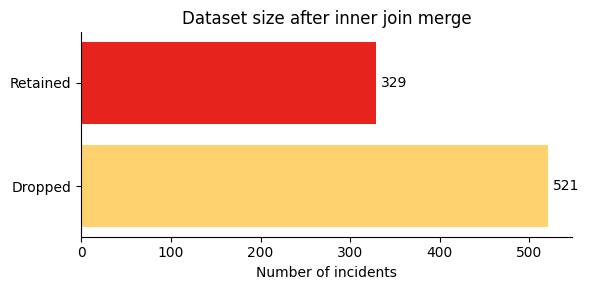

In [3]:
n_raw     = len(df_incidents)
n_merged  = len(df_merged)
n_dropped = n_raw - n_merged

print('=' * 60)
print('MERGE IMPACT')
print('=' * 60)
print(f'  Raw incidents              : {n_raw}')
print(f'  After inner merge          : {n_merged}  ({n_merged/n_raw*100:.1f}% retained)')
print(f'  Dropped (no financial/     ')
print(f'  market data available)     : {n_dropped}  ({n_dropped/n_raw*100:.1f}%)')
print('=' * 60)

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(['Dropped', 'Retained'], [n_dropped, n_merged],
        color=[PALETTE[7], PALETTE[2]])
ax.set_xlabel('Number of incidents')
ax.set_title('Dataset size after inner join merge')
for i, v in enumerate([n_dropped, n_merged]):
    ax.text(v + 5, i, str(v), va='center')
sns.despine()
plt.tight_layout()
plt.show()

## 3. Target Variable: Attack Vector Distribution

"attack_vector_primary" is the classification target used by the KNN classifier and the label basis for the recommender system's relevance definition.

TARGET VARIABLE: attack_vector_primary
                       count     %
attack_vector_primary             
ransomware                84  25.5
data_breach               58  17.6
phishing                  54  16.4
apt                       39  11.9
ddos                      27   8.2
supply_chain              19   5.8
malware                   19   5.8
backdoor                  15   4.6
trojan                    14   4.3

  Classes              : 9
  Most frequent class  : ransomware (84 incidents)
  Least frequent class : trojan (14 incidents)


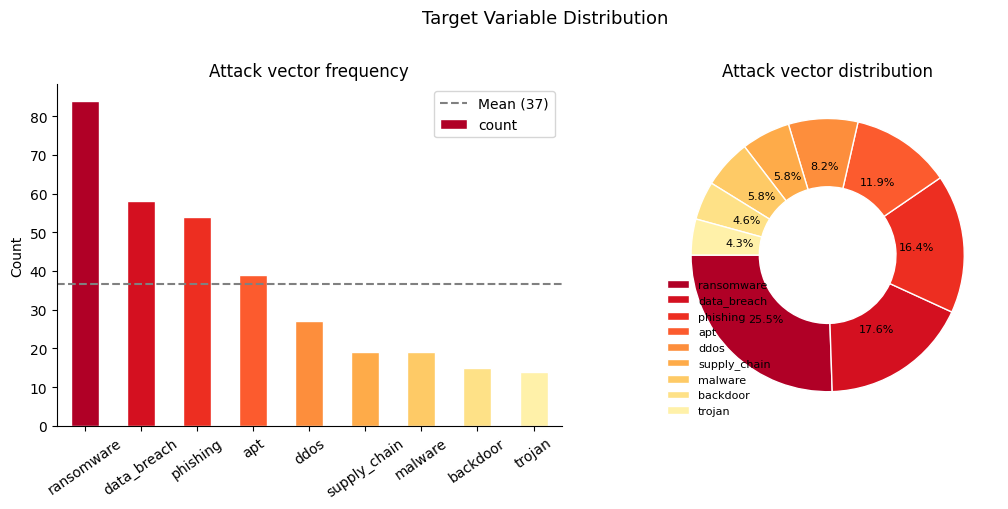

In [4]:
class_counts = df_merged['attack_vector_primary'].value_counts()
class_pct    = class_counts / class_counts.sum() * 100
# ratio = class_counts.max() / class_counts.min()

print('=' * 30)
print('TARGET VARIABLE: attack_vector_primary')
print('=' * 30)
summary = pd.DataFrame({'count': class_counts, '%': class_pct.round(1)})
print(summary.to_string())
print()
print(f'  Classes              : {len(class_counts)}')
print(f'  Most frequent class  : {class_counts.idxmax()} ({class_counts.max()} incidents)')
print(f'  Least frequent class : {class_counts.idxmin()} ({class_counts.min()} incidents)')
print('=' * 30)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Bar chart
colors = sns.color_palette('YlOrRd_r', len(class_counts))
class_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Attack vector frequency')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=35)
axes[0].axhline(class_counts.mean(), linestyle='--', color='gray', label=f'Mean ({class_counts.mean():.0f})')
axes[0].legend()
sns.despine(ax=axes[0])

# Donut chart
wedges, _, autotexts = axes[1].pie(
    class_counts, labels=None, autopct='%1.1f%%',
    colors=colors, startangle=-180,
    pctdistance=0.65,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white', 'width': 0.5})
for t in autotexts:
    t.set_fontsize(8)
axes[1].legend(wedges, class_counts.index, loc='lower left', fontsize=8, frameon=False)
axes[1].set_title('Attack vector distribution')

plt.suptitle('Target Variable Distribution', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Observation

The dataset is quite imbalanced, between the most frequent class (ransomware) and the least (trojan). Ransomware and data_breach together account for over 43% of all incidents. This has two direct implications:

- The stratified split in preprocessing is necessary, since a random split risks placing all samples of rare classes in a single partition
- A KNN classifier evaluated only on accuracy will be misleading, so we do need metrics (precision, recall, F1).

## 4. Temporal Analysis

The dataset spans 2021–2025. Attack patterns evolve over time from 2021 to  2025 new techniques are mastered. If attack vector distributions shift significantly across years, the training set could not represent the test set well.

We visualise incident frequency per year and attack vector evolution over time.

Incidents per year:
year
2021    48
2022    56
2023    56
2024    85
2025    84


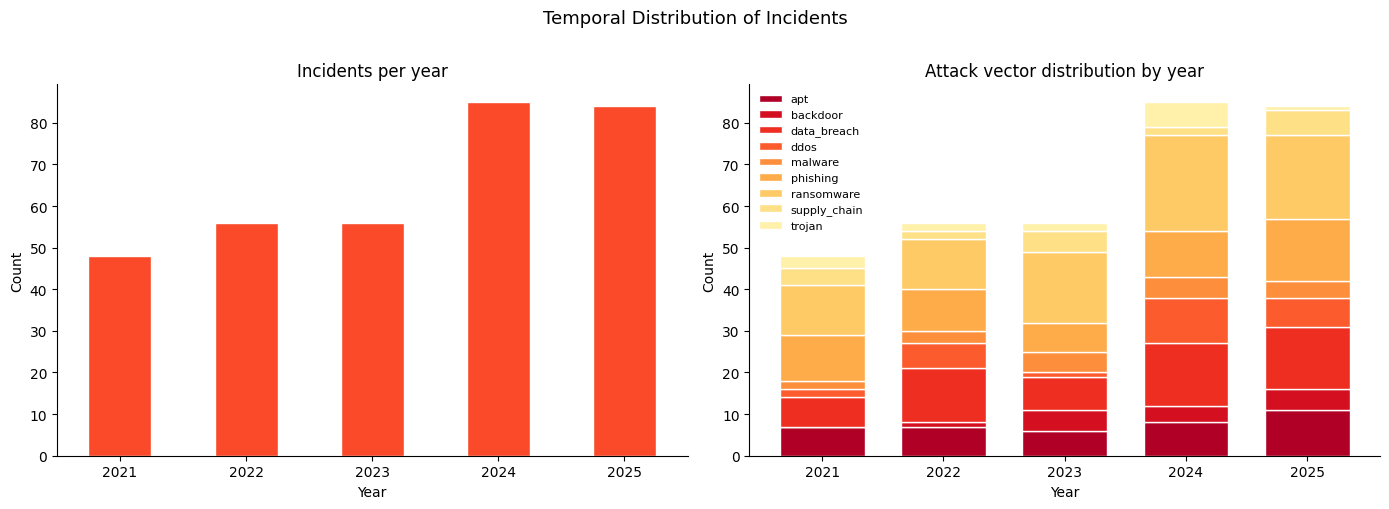

In [5]:
df_merged['incident_date'] = pd.to_datetime(df_merged['incident_date'], errors='coerce')
df_merged['year'] = df_merged['incident_date'].dt.year

yearly_counts  = df_merged['year'].value_counts().sort_index()
yearly_vectors = df_merged.groupby(['year', 'attack_vector_primary']).size().unstack(fill_value=0)

print('Incidents per year:')
print(yearly_counts.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Incidents per year
yearly_counts.plot(kind='bar', ax=axes[0], color=PALETTE[3], edgecolor='white')
axes[0].set_title('Incidents per year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
sns.despine(ax=axes[0])

# Stacked bar: attack vector by year
colors = sns.color_palette('YlOrRd_r', len(yearly_vectors.columns))
yearly_vectors.plot(kind='bar', stacked=True, ax=axes[1], color=colors, edgecolor='white', width=0.7)
axes[1].set_title('Attack vector distribution by year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper left', fontsize=8, frameon=False)
sns.despine(ax=axes[1])

plt.suptitle('Temporal Distribution of Incidents', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Observation

Incident volume increases from 2021 to 2025. Attack vector proportions remain stable across years. This is good for the classifier samples.

## 5. Geographic Distribution

`country_hq` is one of the chosen categorical features. Understanding its distribution reveals whether the dataset is geographically biased — a US-dominated dataset may produce a classifier that underperforms on incidents from other regions.

Total countries represented: 32
US share: 36.2%


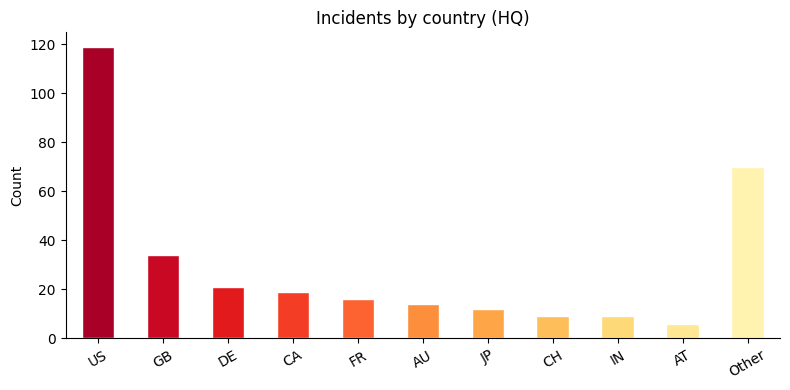

In [6]:
country_counts = df_merged['country_hq'].value_counts()
top_n  = 10
top    = country_counts.head(top_n)
other  = pd.Series({'Other': country_counts.iloc[top_n:].sum()})
combined = pd.concat([top, other])

print(f'Total countries represented: {df_merged["country_hq"].nunique()}')
print(f'US share: {country_counts["US"]/len(df_merged)*100:.1f}%')

fig, ax = plt.subplots(figsize=(8, 4))
colors = sns.color_palette('YlOrRd_r', len(combined))
combined.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Incidents by country (HQ)')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
sns.despine()
plt.tight_layout()
plt.show()

### Observation

The dataset is heavily US dominated (36.2% of incidents). This geographic bias means the classifier's learned patterns are most reliable for US-headquartered companies.

## 6. Processed Feature Distributions

We now turn to the processed data. The scaled dataset `df_full_scaled` reflects the state after imputation and StandardScaler — this is the direct input to the KNN classifier and K-means clustering (in scaled space) and to the recommender system (in original numeric space, before PCA).

We verify that scaling was applied correctly: all features should have mean ≈ 0 and std ≈ 1.

In [7]:
from utils import define_feature_types
num_cols, cat_cols = define_feature_types(df_merged)

## 6. Correlation Structure

The correlation matrix of scaled features shows if there is redundancy between features. Highly correlated feature groups will be compressed by PCA into shared components. However, strong correlations between variables related with attack consequences (loss, recovery) and the ones available for every enterprise (company profile) would indicate that the target can be predicted easely.

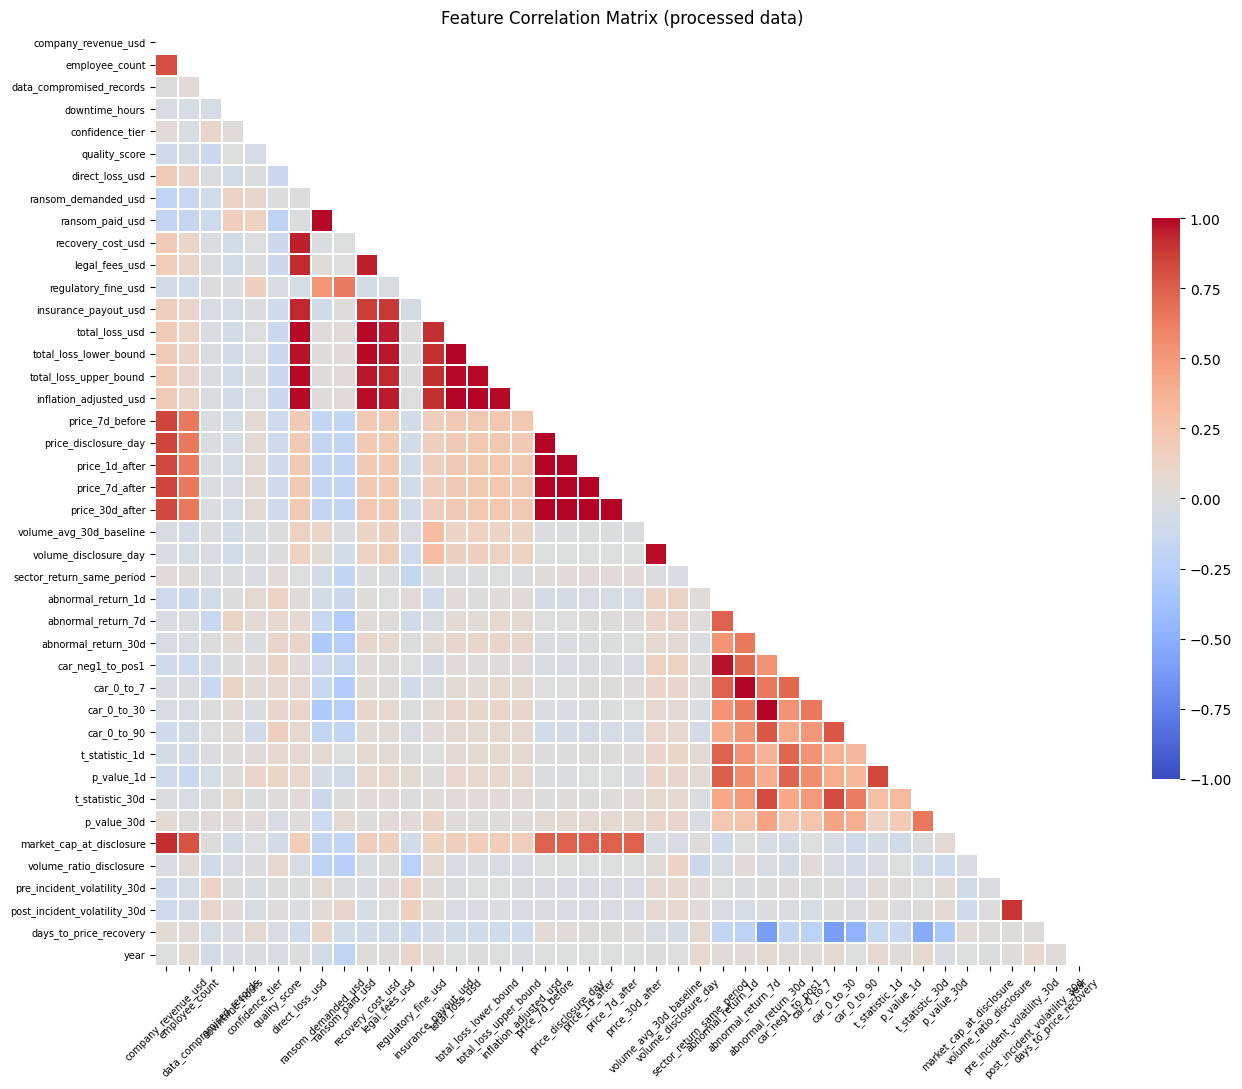


Correlation between company profile and outcome features:


,company_revenue_usd,employee_count,market_cap_at_disclosure,pre_incident_volatility_30d,volume_avg_30d_baseline
total_loss_usd,0.199,0.108,0.174,-0.013,0.131
days_to_price_recovery,0.041,0.038,0.033,0.014,-0.046
downtime_hours,-0.034,-0.048,-0.072,0.003,-0.073
abnormal_return_30d,-0.044,-0.041,-0.043,0.005,0.066


In [ ]:
corr = df_merged[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only
sns.heatmap(
    corr, mask=mask, cmap='coolwarm', center=0,
    vmin=-1, vmax=1, square=True,
    linewidths=0.3, linecolor='white',
    annot=False, ax=ax,
    cbar_kws={'shrink': 0.6})
ax.set_title('Feature Correlation Matrix (processed data)', fontsize=12)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

# Highlight strongest correlations between company profile and outcomes
profile_features = ['company_revenue_usd', 'employee_count', 'market_cap_at_disclosure',
                    'pre_incident_volatility_30d', 'volume_avg_30d_baseline']
outcome_features = ['total_loss_usd', 'days_to_price_recovery', 'downtime_hours', 'abnormal_return_30d']
profile_features = [f for f in profile_features if f in df_merged[num_cols].columns]
outcome_features = [f for f in outcome_features if f in df_merged[num_cols].columns]

if profile_features and outcome_features:
    print('\nCorrelation between company profile and outcome features:')
    display(corr.loc[outcome_features, profile_features].round(3))

### Observation

The correlation between company profile features and outcome variables is very low, meaning the recommender system could find that structural similarity does not predict numerical data.

Strongest correlations: Are within financial outcome variables ("total_loss_usd", "recovery_cost_usd", "legal_fees_usd") and market reaction variables ("abnormal_return_30d", "car_0_to_30").

**same phenomenon from different angles**

PCA will compress the correlated noise into the minimal number of meaningful features.

## 7. Split Validation

The train/val/test split uses stratified sampling to preserve class proportions. We verify that the split was applied correctly and that no class disappears from any partition.

SPLIT SUMMARY
  Total  : 329
  Train  :  131  (39.8%)
  Val    :   99  (30.1%)
  Test   :   99  (30.1%)

Class distribution per split:


,train,val,test
apt,15,12,12
backdoor,6,5,4
data_breach,23,18,17
ddos,11,8,8
malware,8,5,6
phishing,21,16,17
ransomware,33,25,26
supply_chain,8,6,5
trojan,6,4,4



No class missing from any split: True


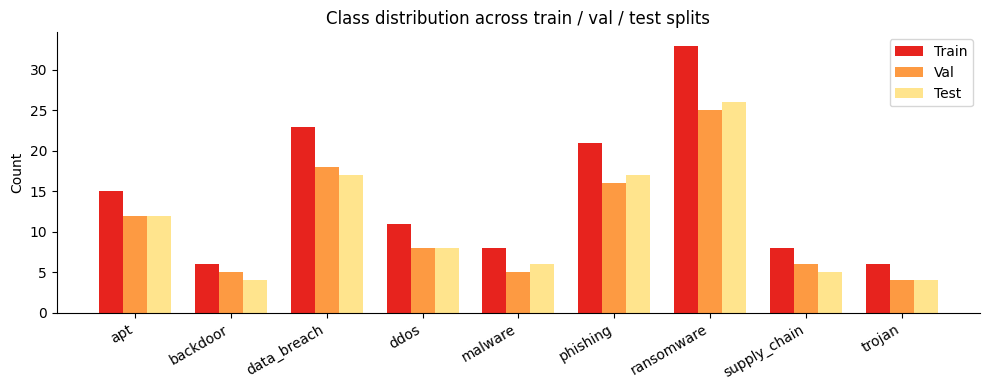

In [ ]:
y_all     = np.concatenate([y_train, y_val, y_test])
classes   = sorted(np.unique(y_all))
n_total   = len(y_all)

print('=' * 65)
print('SPLIT SUMMARY')
print('=' * 65)
print(f'  Total  : {n_total}')
print(f'  Train  : {len(y_train):>4}  ({len(y_train)/n_total*100:.1f}%)')
print(f'  Val    : {len(y_val):>4}  ({len(y_val)/n_total*100:.1f}%)')
print(f'  Test   : {len(y_test):>4}  ({len(y_test)/n_total*100:.1f}%)')
print()

dist = pd.DataFrame({
    'train': [(y_train == c).sum() for c in classes],
    'val'  : [(y_val   == c).sum() for c in classes],
    'test' : [(y_test  == c).sum() for c in classes],
}, index=classes)

print('Class distribution per split:')
display(dist)
print()
print('No class missing from any split:', (dist == 0).sum().sum() == 0)
print('=' * 65)

# Visual
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(classes))
w = 0.25
ax.bar(x - w, dist['train'], w, label='Train', color=PALETTE[2])
ax.bar(x,     dist['val'],   w, label='Val',   color=PALETTE[5])
ax.bar(x + w, dist['test'],  w, label='Test',  color=PALETTE[8])
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=30, ha='right')
ax.set_ylabel('Count')
ax.set_title('Class distribution across train / val / test splits')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

### Observation

All 9 attack vector classes more and less equivalently distributed in proportion along the samples.

## 8. Summary

| Property | Value |
|---|---|
| Raw incidents | 850 |
| After inner merge | 329 (38.7%) |
| Features (numeric) | 36 |
| PCA components (95% var) | 14 |
| Target classes | 9 |
| Temporal range | 2021–2025 |
| Temporal drift | None significant |
| Geographic bias | US-dominated (36%) |

**Key findings:**

- The class imbalance requires stratified evaluation and per-class metrics in the KNN classifier.
- Company profile features (revenue, employees, market cap) are weakly correlated with outcome variables, this suggests that the recommender system will struggle with numerical outcome prediction.
- No temporal drift means the train/test split does not need to be time-ordered